In [6]:
import numpy as np

In [1]:
import anndata as ad

In [2]:
tahoe_a549 = ad.read_h5ad("../../data/degs/tahoe_a549_deg_adata.h5ad")
sciplex_a549 = ad.read_h5ad("../../data/degs/sciplex3_a549_deg_adata.h5ad")

In [77]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1) Make your var_names = gene_symbol and drop duplicates
# -----------------------------------------------------------------
# Assign gene_symbol to var_names (the AnnData "column names" axis)
sciplex_a549.var_names = sciplex_a549.var['gene_symbol'].values
tahoe_a549.var_names  = tahoe_a549.var['gene_symbol'].values

# Drop any duplicate gene_symbols (keeps the first)
keep_sciplex = ~sciplex_a549.var_names.duplicated(keep='first')
keep_tahoe  = ~tahoe_a549.var_names.duplicated(keep='first')

sciplex_a549 = sciplex_a549[:, keep_sciplex].copy()
tahoe_a549  = tahoe_a549[:, keep_tahoe].copy()

# 2) Find the intersection of gene names
# -----------------------------------------------------------------
common_genes = sciplex_a549.var_names.intersection(tahoe_a549.var_names)

# 3) Subset both AnnData's to that shared set (and .copy() so nothing weird leaks)
# -----------------------------------------------------------------
sciplex_sub = sciplex_a549[:, common_genes].copy()
tahoe_sub  = tahoe_a549[:,  common_genes].copy()

# 4) Pull out adj_p_value layers
# -----------------------------------------------------------------
padj_a = sciplex_sub.layers['b']
padj_b = tahoe_sub.layers['b']

# 5) Calculate cosine similarity between adjusted p-values
# -----------------------------------------------------------------
cos_sim = cosine_similarity(padj_a, padj_b)

# 6) Put into a pandas DataFrame
# -----------------------------------------------------------------
sim_df = pd.DataFrame(
    cos_sim,
    index = sciplex_sub.obs_names,
    columns= tahoe_sub.obs_names
)

sim_df

/Users/arturszalata/miniconda3/envs/op3/lib/python3.12/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNMD', 'DPM1', 'SCYL3', 'FGR', 'CFH']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


condition,APTO_253_0_05_uM__A549,APTO_253_0_5_uM__A549,APTO_253_5_0_uM__A549,AT7519_0_05_uM__A549,AT7519_0_5_uM__A549,AT7519_5_0_uM__A549,AZD1390_0_05_uM__A549,AZD1390_0_5_uM__A549,AZD1390_5_0_uM__A549,AZD2858_0_05_uM__A549,...,palbociclib_5_0_uM__A549,venetoclax_0_05_uM__A549,venetoclax_0_5_uM__A549,venetoclax_5_0_uM__A549,vincristine_0_05_uM__A549,vincristine_0_5_uM__A549,vincristine_5_0_uM__A549,γ_Oryzanol_0_05_uM__A549,γ_Oryzanol_0_5_uM__A549,γ_Oryzanol_5_0_uM__A549
condition,,,,,,,,,,,,,,,,,,,,,
AV_939_10000_0_A549,0.971725,0.963026,0.964113,0.970555,0.967285,0.960204,0.958084,0.958220,0.957409,0.962974,...,0.948734,0.951313,0.953945,0.793030,0.956837,0.905105,0.925025,0.971560,0.971745,0.971726
AV_939_1000_0_A549,0.989231,0.979776,0.981522,0.988161,0.984425,0.977503,0.974913,0.975346,0.974527,0.980600,...,0.965532,0.968542,0.970625,0.808117,0.973051,0.921881,0.941623,0.989120,0.989273,0.989269
AV_939_100_0_A549,0.989860,0.980495,0.982330,0.988858,0.985260,0.978349,0.975790,0.975994,0.975296,0.981591,...,0.966649,0.969435,0.971716,0.808778,0.973677,0.921656,0.942130,0.989738,0.989906,0.989923
AV_939_10_0_A549,0.988509,0.979255,0.980962,0.987541,0.983809,0.977036,0.974533,0.974602,0.973779,0.980231,...,0.965006,0.968155,0.970513,0.806497,0.972361,0.920894,0.940501,0.988372,0.988585,0.988515
JQ1_10000_0_A549,0.673024,0.667001,0.668743,0.671794,0.669527,0.665698,0.663297,0.663715,0.662056,0.665524,...,0.657315,0.657920,0.659664,0.553012,0.660850,0.627362,0.639949,0.672530,0.673143,0.673062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
factor_valid_drug_names_ZM_447439_10_0_A549,0.988798,0.979344,0.981023,0.987670,0.983829,0.977194,0.974739,0.974808,0.973968,0.980176,...,0.965101,0.968745,0.970615,0.807587,0.972689,0.921465,0.941344,0.988576,0.988748,0.988725
factor_valid_drug_names_Zileuton_10000_0_A549,0.988414,0.979097,0.980714,0.987341,0.983644,0.977024,0.974616,0.975079,0.973755,0.980219,...,0.964508,0.968161,0.970221,0.807616,0.972454,0.921164,0.940909,0.988227,0.988462,0.988384
factor_valid_drug_names_Zileuton_1000_0_A549,0.991957,0.982628,0.984223,0.990802,0.987189,0.980203,0.978186,0.977719,0.977224,0.983440,...,0.968682,0.971663,0.973640,0.810358,0.975839,0.924032,0.944415,0.991769,0.991982,0.991984


In [ ]:
import pandas as pd
import pubchempy as pcp
from tqdm import tqdm

# (1) Extract unique drug names
tahoe_drugs = pd.Series(tahoe_sub.obs.drug_name.unique(), name='drug_name')
sciplex_drugs = pd.Series(sciplex_sub.obs.drug_name.unique(), name='drug_name')

# Helper to fetch a PubChem CID for a given name (or None if not found)
def get_cid(name):
    try:
        # returns a list of Compound objects; grab the first CID if available
        comps = pcp.get_compounds(name, 'name')
        return comps[0].cid if comps else None
    except Exception:
        return None

# (2) Build mapping DataFrames by querying PubChem
tqdm.pandas(desc="Fetching Tahoe CIDs")
tahoe_map = tahoe_drugs.to_frame().drop_duplicates().assign(
    pubchem_id=lambda df: df['drug_name'].progress_apply(get_cid)
)

tqdm.pandas(desc="Fetching SciPlex CIDs")
sciplex_map = sciplex_drugs.to_frame().drop_duplicates().assign(
    pubchem_id=lambda df: df['drug_name'].progress_apply(get_cid)
)

# (3) Find overlaps
tahoe_cids   = set(tahoe_map['pubchem_id'].dropna())
sciplex_cids = set(sciplex_map['pubchem_id'].dropna())
common_cids  = tahoe_cids & sciplex_cids

# (4) List the drug names that correspond to those shared CIDs
common_tahoe = tahoe_map[tahoe_map['pubchem_id'].isin(common_cids)]['drug_name']
common_sciplex = sciplex_map[sciplex_map['pubchem_id'].isin(common_cids)]['drug_name']

print(f"Number of drugs in Tahoe dataset:      {len(tahoe_drugs)}")
print(f"Number of drugs in SciPlex dataset:    {len(sciplex_drugs)}")
print(f"Number of drugs with matching CIDs:    {len(common_cids)}")
print("\nCommon drugs in Tahoe:")
print(common_tahoe.tolist())
print("\nCommon drugs in SciPlex:")
print(common_sciplex.tolist())

Fetching SciPlex CIDs: 100%|██████████| 188/188 [01:45<00:00,  1.78it/s]

Number of drugs in Tahoe dataset:      379
Number of drugs in SciPlex dataset:    188
Number of drugs with matching CIDs:    22

Common drugs in Tahoe:
['Altretamine', 'Belinostat', 'Busulfan', 'Celecoxib', 'Decitabine', 'Filgotinib', 'Fulvestrant', 'Lapatinib ditosylate', 'Panobinostat', 'Raltitrexed', 'Regorafenib', 'Resveratrol', 'Roxadustat', 'Rucaparib (phosphate)', 'TAK-901', 'Tofacitinib (citrate)', 'Trametinib', 'Vandetanib', '5-Azacytidine', '5-Fluorouracil', 'Zileuton', 'crizotinib']

Common drugs in SciPlex:
['Altretamine', 'Azacitidine ', 'Belinostat (PXD101)', 'Busulfan ', 'Celecoxib', 'Crizotinib (PF-02341066)', 'Decitabine', 'Filgotinib (GLPG0634)', 'Fluorouracil (5-Fluoracil, 5-FU)', 'Fulvestrant', 'Lapatinib (GW-572016) Ditosylate', 'Panobinostat (LBH589)', 'Raltitrexed', 'Regorafenib (BAY 73-4506)', 'Resveratrol', 'Roxadustat (FG-4592)', 'Rucaparib (AG-014699,PF-01367338) phosphate', 'TAK-901', 'Tofacitinib (CP-690550) Citrate', 'Trametinib (GSK1120212)', 'Vandetanib 

In [78]:
tahoe_sub.obs['pubchem_cid'] = tahoe_sub.obs['drug_name'].map(tahoe_map.set_index('drug_name')['pubchem_id'])
sciplex_sub.obs['pubchem_cid'] = sciplex_sub.obs['drug_name'].map(sciplex_map.set_index('drug_name')['pubchem_id'])

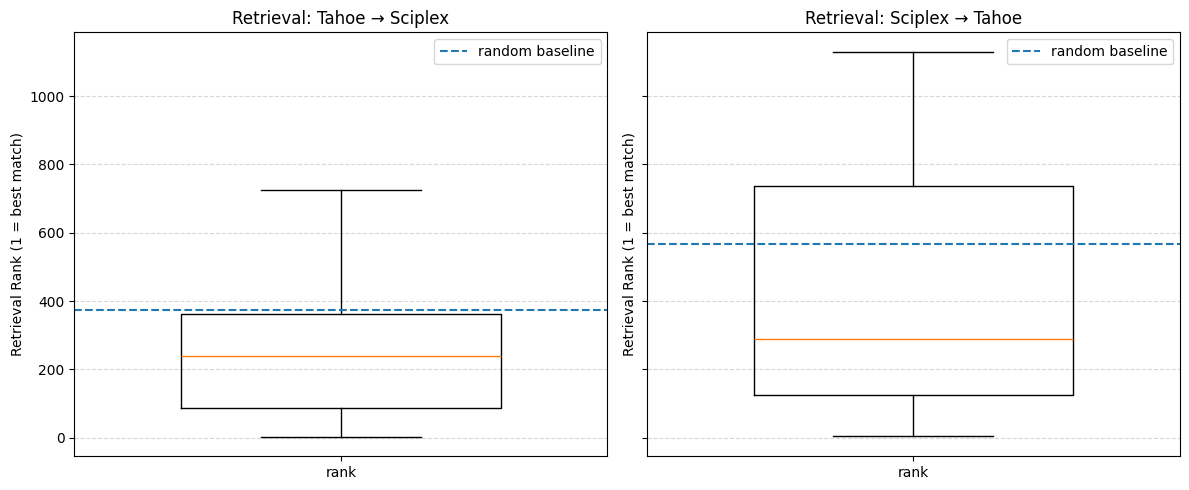


Median retrieval ranks:
Tahoe→Sciplex: 238.0 (random baseline: 375.0)
Sciplex→Tahoe: 287.5 (random baseline: 566.5)


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_matches(label, obs_a, obs_b):
    meta = obs_a.loc[label]
    cid, dose = meta['pubchem_cid'], meta['dosage_uM']
    sub = obs_b[obs_b['pubchem_cid'] == cid]
    if sub.empty:
        return []
    lower = sub[sub['dosage_uM'] <= dose]
    higher = sub[sub['dosage_uM'] >= dose]
    matches = []
    if not lower.empty:
        closest_low = lower['dosage_uM'].max()
        matches += lower[lower['dosage_uM'] == closest_low].index.tolist()
    if not higher.empty:
        closest_high = higher['dosage_uM'].min()
        for idx in higher[higher['dosage_uM'] == closest_high].index:
            if idx not in matches:
                matches.append(idx)
    return matches

def compute_retrieval_ranks(sim, obs_q, obs_db):
    ranks = {}
    for q in sim.index:
        true_bs = find_matches(q, obs_q, obs_db)
        if not true_bs:
            ranks[q] = np.nan
            continue
        sorted_cols = sim.loc[q].sort_values(ascending=False).index
        pos = [np.where(sorted_cols == b)[0][0] + 1 for b in true_bs if b in sorted_cols]
        ranks[q] = min(pos) if pos else np.nan
    return pd.Series(ranks, name='rank')

# 1) Tahoe→Sciplex
ranks_t2s = compute_retrieval_ranks(sim_df.T, tahoe_sub.obs, sciplex_sub.obs)
# 2) Sciplex→Tahoe
ranks_s2t = compute_retrieval_ranks(sim_df, sciplex_sub.obs, tahoe_sub.obs)

# baseline: random expected rank = (N+1)/2
n_sciplex = sim_df.shape[0]
n_tahoe   = sim_df.shape[1]
rand_t2s = (n_sciplex + 1) / 2
rand_s2t = (n_tahoe   + 1) / 2

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].boxplot(ranks_t2s.dropna(), widths=0.6)
axes[0].axhline(rand_t2s, linestyle='--', label='random baseline')
axes[0].set_title("Retrieval: Tahoe → Sciplex")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["rank"])
axes[0].legend()

axes[1].boxplot(ranks_s2t.dropna(), widths=0.6)
axes[1].axhline(rand_s2t, linestyle='--', label='random baseline')
axes[1].set_title("Retrieval: Sciplex → Tahoe")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["rank"])
axes[1].legend()

for ax in axes:
    ax.set_ylabel("Retrieval Rank (1 = best match)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print median retrieval ranks
print("\nMedian retrieval ranks:")
print(f"Tahoe→Sciplex: {ranks_t2s.median():.1f} (random baseline: {rand_t2s:.1f})")
print(f"Sciplex→Tahoe: {ranks_s2t.median():.1f} (random baseline: {rand_s2t:.1f})")

In [84]:
# -----------------------------------------------------------------
lfc_a = sciplex_sub.layers['logfc']
lfc_b = tahoe_sub.layers['logfc']
padj_a = sciplex_sub.layers['adj_p_value']
padj_b = tahoe_sub.layers['adj_p_value']

# 5) Build signed –log10-pval signatures (more standard than sign * log10)
# -----------------------------------------------------------------
signed_a = np.sign(lfc_a) * -np.log10(padj_a)
signed_b = np.sign(lfc_b) * -np.log10(padj_b)

# 6) Cosine-similarity between every A vs. every B contrast
# -----------------------------------------------------------------
cos_sim = cosine_similarity(signed_a, signed_b)

# 7) Put into a pandas DataFrame
# -----------------------------------------------------------------
sim_df = pd.DataFrame(
    cos_sim,
    index = sciplex_sub.obs_names,
    columns= tahoe_sub.obs_names
)

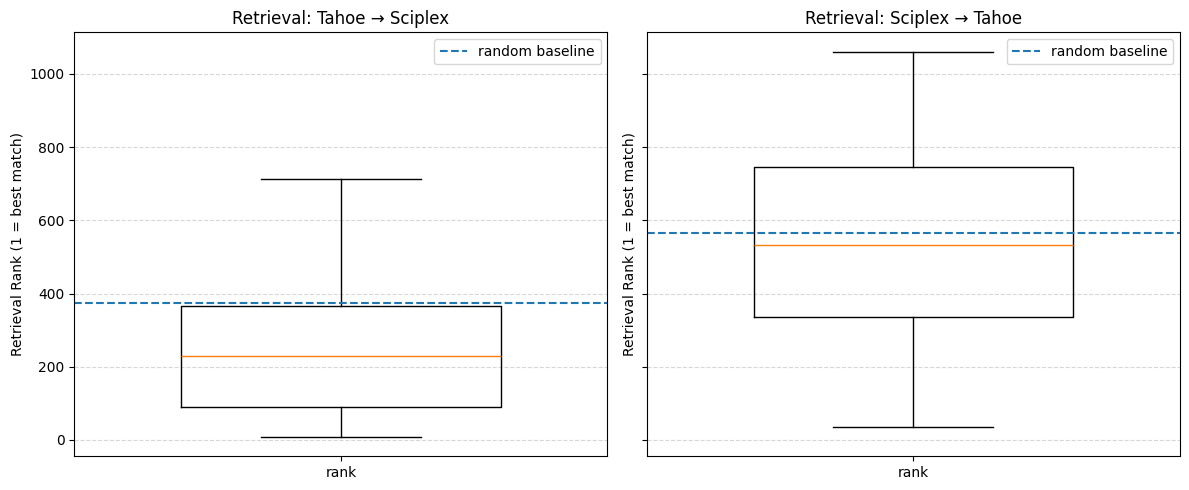


Median retrieval ranks:
Tahoe→Sciplex: 230.0 (random baseline: 375.0)
Sciplex→Tahoe: 533.0 (random baseline: 566.5)


In [85]:
def find_matches(label, obs_a, obs_b):
    meta = obs_a.loc[label]
    cid, dose = meta['pubchem_cid'], meta['dosage_uM']
    sub = obs_b[obs_b['pubchem_cid'] == cid]
    if sub.empty:
        return []
    lower = sub[sub['dosage_uM'] <= dose]
    higher = sub[sub['dosage_uM'] >= dose]
    matches = []
    if not lower.empty:
        closest_low = lower['dosage_uM'].max()
        matches += lower[lower['dosage_uM'] == closest_low].index.tolist()
    if not higher.empty:
        closest_high = higher['dosage_uM'].min()
        for idx in higher[higher['dosage_uM'] == closest_high].index:
            if idx not in matches:
                matches.append(idx)
    return matches

def compute_retrieval_ranks(sim, obs_q, obs_db):
    ranks = {}
    for q in sim.index:
        true_bs = find_matches(q, obs_q, obs_db)
        if not true_bs:
            ranks[q] = np.nan
            continue
        sorted_cols = sim.loc[q].sort_values(ascending=False).index
        pos = [np.where(sorted_cols == b)[0][0] + 1 for b in true_bs if b in sorted_cols]
        ranks[q] = min(pos) if pos else np.nan
    return pd.Series(ranks, name='rank')

# 1) Tahoe→Sciplex
ranks_t2s = compute_retrieval_ranks(sim_df.T, tahoe_sub.obs, sciplex_sub.obs)
# 2) Sciplex→Tahoe
ranks_s2t = compute_retrieval_ranks(sim_df, sciplex_sub.obs, tahoe_sub.obs)

# baseline: random expected rank = (N+1)/2
n_sciplex = sim_df.shape[0]
n_tahoe   = sim_df.shape[1]
rand_t2s = (n_sciplex + 1) / 2
rand_s2t = (n_tahoe   + 1) / 2

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].boxplot(ranks_t2s.dropna(), widths=0.6)
axes[0].axhline(rand_t2s, linestyle='--', label='random baseline')
axes[0].set_title("Retrieval: Tahoe → Sciplex")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["rank"])
axes[0].legend()

axes[1].boxplot(ranks_s2t.dropna(), widths=0.6)
axes[1].axhline(rand_s2t, linestyle='--', label='random baseline')
axes[1].set_title("Retrieval: Sciplex → Tahoe")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["rank"])
axes[1].legend()

for ax in axes:
    ax.set_ylabel("Retrieval Rank (1 = best match)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print median retrieval ranks
print("\nMedian retrieval ranks:")
print(f"Tahoe→Sciplex: {ranks_t2s.median():.1f} (random baseline: {rand_t2s:.1f})")
print(f"Sciplex→Tahoe: {ranks_s2t.median():.1f} (random baseline: {rand_s2t:.1f})")

/Users/arturszalata/miniconda3/envs/op3/lib/python3.12/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNMD', 'DPM1', 'SCYL3', 'FGR', 'CFH']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


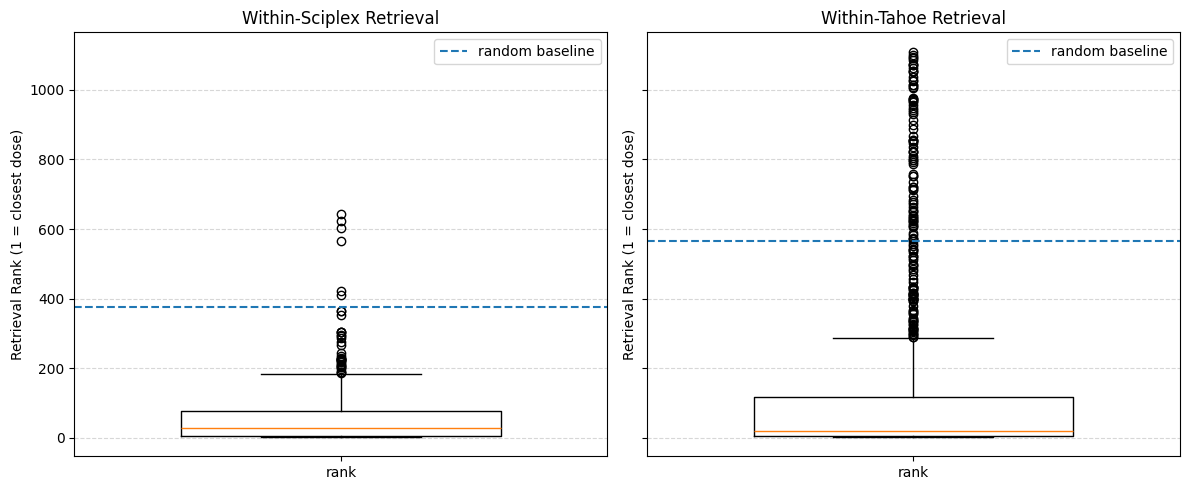


Median retrieval ranks:
Within-Sciplex: 27.5 (random baseline: 375.0)
Within-Tahoe:   18.0 (random baseline: 566.5)


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def prepare_signed_padj(adata):
    # set gene_symbol as var_names and drop duplicates
    adata.var_names = adata.var['gene_symbol'].values
    keep = ~adata.var_names.duplicated(keep='first')
    adata = adata[:, keep].copy()
    # build signed –log10(p) signature
    lfc   = adata.layers['logfc']
    padj  = adata.layers['adj_p_value']
    signed = np.sign(lfc) * -np.log10(padj)
    return signed, adata.obs

def compute_sim_df(signed, obs):
    sims = cosine_similarity(signed, signed)
    return pd.DataFrame(sims, index=obs.index, columns=obs.index)

def find_matches(label, obs):
    meta = obs.loc[label]
    cid, dose = meta['pubchem_cid'], meta['dosage_uM']
    sub = obs[obs['pubchem_cid'] == cid]
    if sub.empty:
        return []
    lower  = sub[sub['dosage_uM'] < dose]
    higher = sub[sub['dosage_uM'] > dose]
    matches = []
    if not lower.empty:
        d_low = lower['dosage_uM'].max()
        matches += lower[lower['dosage_uM'] == d_low].index.tolist()
    if not higher.empty:
        d_high = higher['dosage_uM'].min()
        for idx in higher[higher['dosage_uM'] == d_high].index:
            if idx not in matches:
                matches.append(idx)
    # exclude self-match if dose exactly equals
    return [m for m in matches if m != label]

def compute_retrieval_ranks(sim_df, obs):
    ranks = {}
    for q in sim_df.index:
        true_bs = find_matches(q, obs)
        if not true_bs:
            ranks[q] = np.nan
            continue
        sorted_idx = sim_df.loc[q].sort_values(ascending=False).index
        positions = [np.where(sorted_idx == b)[0][0] + 1
                     for b in true_bs if b in sorted_idx]
        ranks[q] = min(positions) if positions else np.nan
    return pd.Series(ranks, name='rank')

# prepare both datasets
signed_sci, obs_sci   = prepare_signed_padj(sciplex_sub)
signed_tah, obs_tah   = prepare_signed_padj(tahoe_sub)

# compute within‐dataset similarity matrices
sim_sci = compute_sim_df(signed_sci, obs_sci)
sim_tah = compute_sim_df(signed_tah, obs_tah)

# compute retrieval ranks
ranks_sci = compute_retrieval_ranks(sim_sci, obs_sci)
ranks_tah = compute_retrieval_ranks(sim_tah, obs_tah)

# random‐baseline = (N+1)/2
rand_sci = (sim_sci.shape[0] + 1) / 2
rand_tah = (sim_tah.shape[0] + 1) / 2

# plot side‐by‐side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].boxplot(ranks_sci.dropna(), widths=0.6)
axes[0].axhline(rand_sci, linestyle='--', label='random baseline')
axes[0].set_title("Within-Sciplex Retrieval")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["rank"])
axes[0].legend()

axes[1].boxplot(ranks_tah.dropna(), widths=0.6)
axes[1].axhline(rand_tah, linestyle='--', label='random baseline')
axes[1].set_title("Within-Tahoe Retrieval")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["rank"])
axes[1].legend()

for ax in axes:
    ax.set_ylabel("Retrieval Rank (1 = closest dose)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print median retrieval ranks
print("\nMedian retrieval ranks:")
print(f"Within-Sciplex: {ranks_sci.median():.1f} (random baseline: {rand_sci:.1f})")
print(f"Within-Tahoe:   {ranks_tah.median():.1f} (random baseline: {rand_tah:.1f})")

condition,APTO_253_0_05_uM__A549,APTO_253_0_5_uM__A549,APTO_253_5_0_uM__A549,AT7519_0_05_uM__A549,AT7519_0_5_uM__A549,AT7519_5_0_uM__A549,AZD1390_0_05_uM__A549,AZD1390_0_5_uM__A549,AZD1390_5_0_uM__A549,AZD2858_0_05_uM__A549,...,palbociclib_5_0_uM__A549,venetoclax_0_05_uM__A549,venetoclax_0_5_uM__A549,venetoclax_5_0_uM__A549,vincristine_0_05_uM__A549,vincristine_0_5_uM__A549,vincristine_5_0_uM__A549,γ_Oryzanol_0_05_uM__A549,γ_Oryzanol_0_5_uM__A549,γ_Oryzanol_5_0_uM__A549
condition,,,,,,,,,,,,,,,,,,,,,
AV_939_10000_0_A549,0.971725,0.963026,0.964113,0.970555,0.967285,0.960204,0.958084,0.958220,0.957409,0.962974,...,0.948734,0.951313,0.953945,0.793030,0.956837,0.905105,0.925025,0.971560,0.971745,0.971726
AV_939_1000_0_A549,0.989231,0.979776,0.981522,0.988161,0.984425,0.977503,0.974913,0.975346,0.974527,0.980600,...,0.965532,0.968542,0.970625,0.808117,0.973051,0.921881,0.941623,0.989120,0.989273,0.989269
AV_939_100_0_A549,0.989860,0.980495,0.982330,0.988858,0.985260,0.978349,0.975790,0.975994,0.975296,0.981591,...,0.966649,0.969435,0.971716,0.808778,0.973677,0.921656,0.942130,0.989738,0.989906,0.989923
AV_939_10_0_A549,0.988509,0.979255,0.980962,0.987541,0.983809,0.977036,0.974533,0.974602,0.973779,0.980231,...,0.965006,0.968155,0.970513,0.806497,0.972361,0.920894,0.940501,0.988372,0.988585,0.988515
JQ1_10000_0_A549,0.673024,0.667001,0.668743,0.671794,0.669527,0.665698,0.663297,0.663715,0.662056,0.665524,...,0.657315,0.657920,0.659664,0.553012,0.660850,0.627362,0.639949,0.672530,0.673143,0.673062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
factor_valid_drug_names_ZM_447439_10_0_A549,0.988798,0.979344,0.981023,0.987670,0.983829,0.977194,0.974739,0.974808,0.973968,0.980176,...,0.965101,0.968745,0.970615,0.807587,0.972689,0.921465,0.941344,0.988576,0.988748,0.988725
factor_valid_drug_names_Zileuton_10000_0_A549,0.988414,0.979097,0.980714,0.987341,0.983644,0.977024,0.974616,0.975079,0.973755,0.980219,...,0.964508,0.968161,0.970221,0.807616,0.972454,0.921164,0.940909,0.988227,0.988462,0.988384
factor_valid_drug_names_Zileuton_1000_0_A549,0.991957,0.982628,0.984223,0.990802,0.987189,0.980203,0.978186,0.977719,0.977224,0.983440,...,0.968682,0.971663,0.973640,0.810358,0.975839,0.924032,0.944415,0.991769,0.991982,0.991984
